## Data Structure

In [2]:
import numpy as np
import matplotlib.pyplot as plt

hap1 = np.load('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/processed_data/hap1.npy')
hap2 = np.load('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/processed_data/hap2.npy')

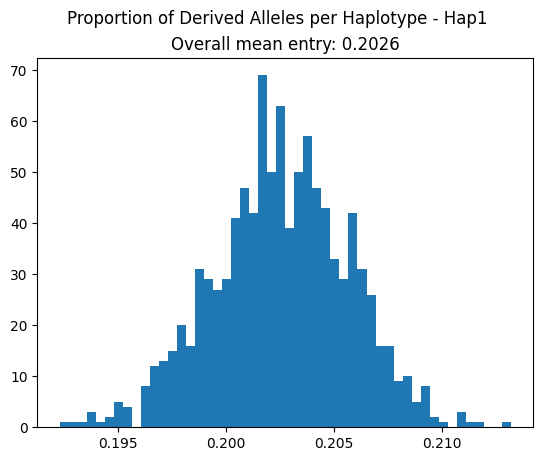

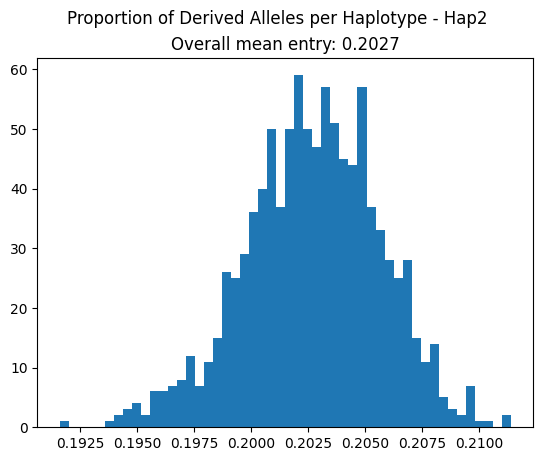

In [6]:
hap1_mean = hap1.mean(axis=1)
plt.figure()
plt.suptitle('Proportion of Derived Alleles per Haplotype - Hap1')
plt.title(f'Overall mean entry: {hap1.mean():.4f}')
plt.hist(hap1_mean, bins=50)
plt.show()

hap2_mean = hap2.mean(axis=1)
plt.figure()
plt.suptitle('Proportion of Derived Alleles per Haplotype - Hap2')
plt.title(f'Overall mean entry: {hap2.mean():.4f}')
plt.hist(hap2_mean, bins=50)
plt.show()


In [7]:
import pickle
with open('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/processed_data/hap_meta.pkl', 'rb') as f:
    hap_meta = pickle.load(f)

/tmp/ipykernel_1062127/767973884.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  hap_meta = pickle.load(f)


In [8]:
hap_meta

,individual_id,population,hap_id,hap_index
0,0,YRI,0,0
1,1,YRI,0,1
2,2,YRI,0,2
3,3,YRI,0,3
4,4,YRI,0,4
...,...,...,...,...
1995,995,CEU,1,1995
1996,996,CEU,1,1996
1997,997,CEU,1,1997
1998,998,CEU,1,1998


Plotted lags: 200 / 200


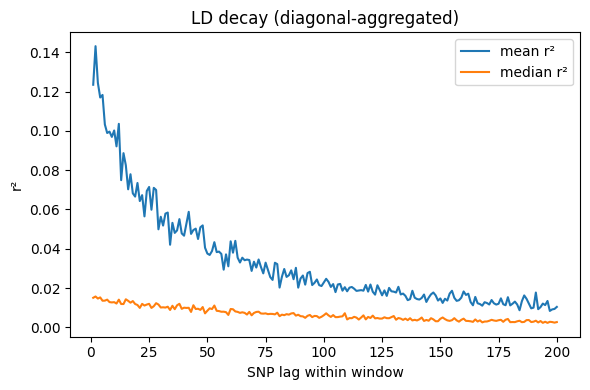

In [12]:
Hbase = np.concatenate([hap1, hap2], axis=0)  # (2N, M)

window_len = 400
start = np.random.randint(0, Hbase.shape[1] - window_len)
H = Hbase[:, start:start + window_len].astype(float)

H -= H.mean(axis=0)
corr = np.corrcoef(H, rowvar=False)
corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
r2 = corr**2


# ---- LD decay by lag: use diagonal means/medians ----
M = r2.shape[0]
max_lag = min(200, M-1)
lags = np.arange(1, max_lag+1)

mean_r2 = np.array([np.mean(np.diag(r2, k=k)) for k in lags])
med_r2  = np.array([np.median(np.diag(r2, k=k)) for k in lags])
counts  = np.array([np.diag(r2, k=k).size for k in lags])

# only keep lags with enough pairs
min_pairs = 50
mask = counts >= min_pairs

print("Plotted lags:", mask.sum(), "/", mask.size)

plt.figure(figsize=(6,4))
plt.plot(lags[mask], mean_r2[mask], label="mean r²")
plt.plot(lags[mask], med_r2[mask],  label="median r²")
plt.xlabel("SNP lag within window")
plt.ylabel("r²")
plt.title("LD decay (diagonal-aggregated)")
plt.legend()
plt.tight_layout()
plt.show()


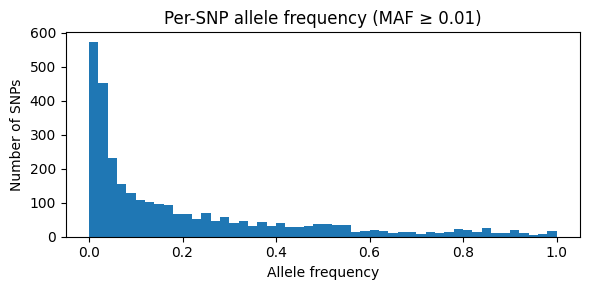

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# combine both haplotypes to get population allele frequency
Hbase = np.concatenate([hap1_f, hap2_f], axis=0)

plt.figure(figsize=(6,3))
plt.hist(p_filt, bins=50, range=(0,1))
plt.xlabel("Allele frequency")
plt.ylabel("Number of SNPs")
plt.title(f"Per-SNP allele frequency (MAF ≥ {maf_thresh})")
plt.tight_layout()
plt.show()



## Probing Data Class

In [40]:
import sys
from pathlib import Path
import os
import torch

# Get the project root (parent directory of notebooks folder)
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.transformer.data_class import HapBatch, HapDataset, collate_hapbatch
from src.transformer.splitting import make_train_val_test_loaders


In [41]:
hap = np.load('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/processed_data/hap1.npy')
pad_id = None
window_len = 512
window_mode = "random"
fixed_start = 0
seed = 295

In [42]:
# ---------------------
# Seeds + device
# ---------------------
torch.manual_seed(int(seed))
np.random.seed(int(seed))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------
# Load hap
# ---------------------
if hap.ndim != 2:
    raise ValueError(f"--hap must be 2D (N,L). Got {hap_np.shape}")
hap = torch.from_numpy(hap).long()

In [43]:
ds = HapDataset(
    hap_all=hap,
    window_len=window_len,
    window_mode=window_mode,
    fixed_start=fixed_start,
    seed=int(seed),
)

In [45]:
batch_size = 64
num_workers = 0
train_frac = 0.8
val_frac = 0.1
test_frac = 0.1

In [46]:
train_dl, val_dl, test_dl, n_tr, n_va, n_te = make_train_val_test_loaders(
    ds,
    batch_size=int(batch_size),
    num_workers=int(num_workers),
    seed=int(seed),
    train_frac=float(train_frac),
    val_frac=float(val_frac),
    test_frac=float(test_frac),
    device=device,
    collate_fn=collate_hapbatch,
)

In [50]:
a = next(iter(train_dl))

In [54]:
a.hap.shape

torch.Size([64, 512])

In [ ]:
from src.transformer.model import HapMaskTransformer
# vocab_size: int,
# d_model: int = 128,
# n_heads: int = 8,
# n_layers: int = 6,
# dropout: float = 0.1,
# max_len: int = 50_000,
# pad_id: int | None = None,
# pool: str = "mean",  # "mean" only for now

In [56]:
mdl = HapMaskTransformer(
    vocab_size=3,
    d_model=128,
    n_heads=8,
    n_layers=6,
    dropout=0.1,
    max_len=50_000,
    pad_id=pad_id,
    pool="mean"
)

/home/akapoor/miniconda3/envs/snakemake-env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [57]:
lr = 1e-4
weight_decay = 1e-2

In [58]:
opt = torch.optim.AdamW(
    mdl.parameters(),
    lr=float(lr),
    weight_decay=float(weight_decay),
)

In [63]:
mdl(hap, pad_mask=None)

RuntimeError: [enforce fail at alloc_cpu.cpp:124] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 3200000000000 bytes. Error code 12 (Cannot allocate memory)

In [ ]:
""